## Latency sweep — 10 robots on `libero_10` (job 2479799)

Plots **success rate per robot** vs. **injected latency (ms)**.

Data layout:
```
data/libero/sweep_latency_10robots/
  latency_{X}ms_job2479799/
    runtime_metadata.json
    {robot_idx}/
      {ep_idx}_{suite}_{task_id}_{success|failure}/
        metadata.json
```

In [11]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
JOB_ID = "2479760"
SWEEP_ROOT = PROJECT_ROOT / "data" / "libero" / "sweep_latency_10robots"

assert SWEEP_ROOT.exists(), f"Missing: {SWEEP_ROOT}"
print(f"Project root : {PROJECT_ROOT}")
print(f"Sweep root   : {SWEEP_ROOT}")

Project root : /coc/flash7/rbansal66/vvla/openpi
Sweep root   : /coc/flash7/rbansal66/vvla/openpi/data/libero/sweep_latency_10robots


In [12]:
DIR_RE = re.compile(r"^latency_(\d+)ms_job" + JOB_ID + r"$")

records = []

for run_dir in sorted(SWEEP_ROOT.iterdir()):
    m = DIR_RE.match(run_dir.name)
    if not m:
        continue
    latency_ms = int(m.group(1))

    for robot_dir in sorted(run_dir.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else -1):
        if not robot_dir.is_dir() or not robot_dir.name.isdigit():
            continue
        robot_idx = int(robot_dir.name)

        for ep_dir in robot_dir.iterdir():
            meta_path = ep_dir / "metadata.json"
            if not meta_path.exists():
                continue
            with meta_path.open() as f:
                meta = json.load(f)
            records.append({
                "latency_ms": latency_ms,
                "robot_idx": robot_idx,
                "task_id": meta["task_id"],
                "episode_idx": meta["episode_idx"],
                "success": bool(meta["success"]),
            })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} episodes across {df['latency_ms'].nunique()} latency values and {df['robot_idx'].nunique()} robots")
df.head()

Loaded 133 episodes across 7 latency values and 10 robots


,latency_ms,robot_idx,task_id,episode_idx,success
0,0,0,1,2,True
1,0,0,1,1,True
2,0,1,0,1,True
3,0,1,0,2,True
4,0,3,2,1,True


In [13]:
# Success rate per (robot, latency)
grp = df.groupby(["latency_ms", "robot_idx"])["success"]
rates = (
    pd.concat([grp.sum().rename("num_successes"), grp.count().rename("num_episodes")], axis=1)
    .reset_index()
)
rates["success_rate"] = rates["num_successes"] / rates["num_episodes"]
print(f"Episodes per (robot, latency): {rates['num_episodes'].unique()}")
rates.head(20)

Episodes per (robot, latency): [2 1]


,latency_ms,robot_idx,num_successes,num_episodes,success_rate
0,0,0,2,2,1.0
1,0,1,2,2,1.0
2,0,3,2,2,1.0
3,0,4,2,2,1.0
4,0,5,2,2,1.0
5,0,6,2,2,1.0
6,0,7,2,2,1.0
7,0,8,2,2,1.0
8,0,9,2,2,1.0
9,50,0,2,2,1.0


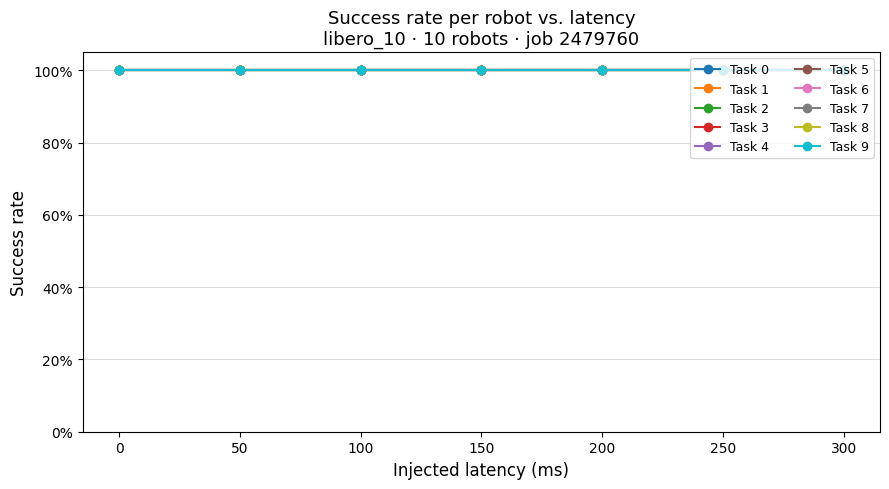

In [14]:
latencies = sorted(rates["latency_ms"].unique())
robots = sorted(rates["robot_idx"].unique())

cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(9, 5))

for robot_idx in robots:
    robot_data = rates[rates["robot_idx"] == robot_idx].set_index("latency_ms")["success_rate"]
    ys = [robot_data.get(lat, np.nan) for lat in latencies]
    ax.plot(latencies, ys, marker="o", label=f"Task {robot_idx}", color=cmap(robot_idx % 10))

ax.set_xlabel("Injected latency (ms)", fontsize=12)
ax.set_ylabel("Success rate", fontsize=12)
ax.set_title(f"Success rate per robot vs. latency\nlibero_10 · 10 robots · job {JOB_ID}", fontsize=13)
ax.set_xticks(latencies)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(axis="y", alpha=0.4)
ax.legend(loc="upper right", ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / f"sweep_latency_10robots_{JOB_ID}.png", dpi=150)
plt.show()

In [15]:
# Summary: mean ± std success rate across robots at each latency
summary = rates.groupby("latency_ms")["success_rate"].agg(["mean", "std", "min", "max"])
print(summary.to_string(float_format="{:.3f}".format))

            mean   std   min   max
latency_ms                        
0          1.000 0.000 1.000 1.000
50         1.000 0.000 1.000 1.000
100        1.000 0.000 1.000 1.000
150        1.000 0.000 1.000 1.000
200        1.000 0.000 1.000 1.000
250        1.000 0.000 1.000 1.000
300        1.000 0.000 1.000 1.000
